In [1]:
%load_ext autoreload
%autoreload 2
from seek_code import SEEK
from data_handler import EleHandler
from classifier import Classifier
from backbone import Backbone
from concept_head import ConceptHead
from projector import Projector

from torch.utils.data import DataLoader, Subset
from torch.utils.data.sampler import RandomSampler

import torch, math
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import random
from collections import Counter
import matplotlib.pyplot as plt

/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data

In [2]:
# Random Sampling
#dataset = EleHandler(subset='EFA_IDI')
#indices = random.sample(range(len(dataset)), len(dataset))
#train_indices, val_indices, test_indices = indices[:int(0.7*len(indices))], indices[int(0.7*len(indices)):int(0.85*len(indices))], indices[int(0.85*len(indices)):]

# Cutting along enconters
#dataset = EleHandler(subset='EFA_IDI')
#train_indices, val_indices, test_indices = dataset.split_along_encounters([0.7,0.15,0.15], hour_delta=4)

# Only 9 images per elephants, split perpendicular to elephants, along encounters if possible
dataset = EleHandler(subset='IDI_with_6_images')
train_indices, val_indices, test_indices = dataset.split_perpendicular_to_elephants([0.6,0.2,0.2]) 

print('Train:', len(train_indices), 'Validation:', len(val_indices), 'Test:', len(test_indices))
assert not (set(train_indices) & set(val_indices)), "Train and Validation sets overlap!"
assert not (set(train_indices) & set(test_indices)), "Train and Test sets overlap!"
assert not (set(val_indices) & set(test_indices)), "Validation and Test sets overlap!"

train_subset = Subset(dataset, train_indices)
val_subset = Subset(dataset, val_indices)
test_subset = Subset(dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=128, shuffle=False, num_workers=4)
val_loader = DataLoader(val_subset, batch_size=128, shuffle=False, num_workers=4)
test_loader = DataLoader(test_subset, batch_size=128, shuffle=False, num_workers=4)

# Check the values of the labels
max_ele_label = 0
for batch in train_loader:
    max_ele_label = max(torch.max(batch[2]), max_ele_label)

print('Number of elephants:', max_ele_label.item() + 1)

num_classes = max_ele_label.item() + 1
code = 'small_Elephant_Classifier'

Train indices: 1838, Validation indices: 532, Test indices: 924
Train: 1838 Validation: 532 Test: 924
Number of elephants: 310


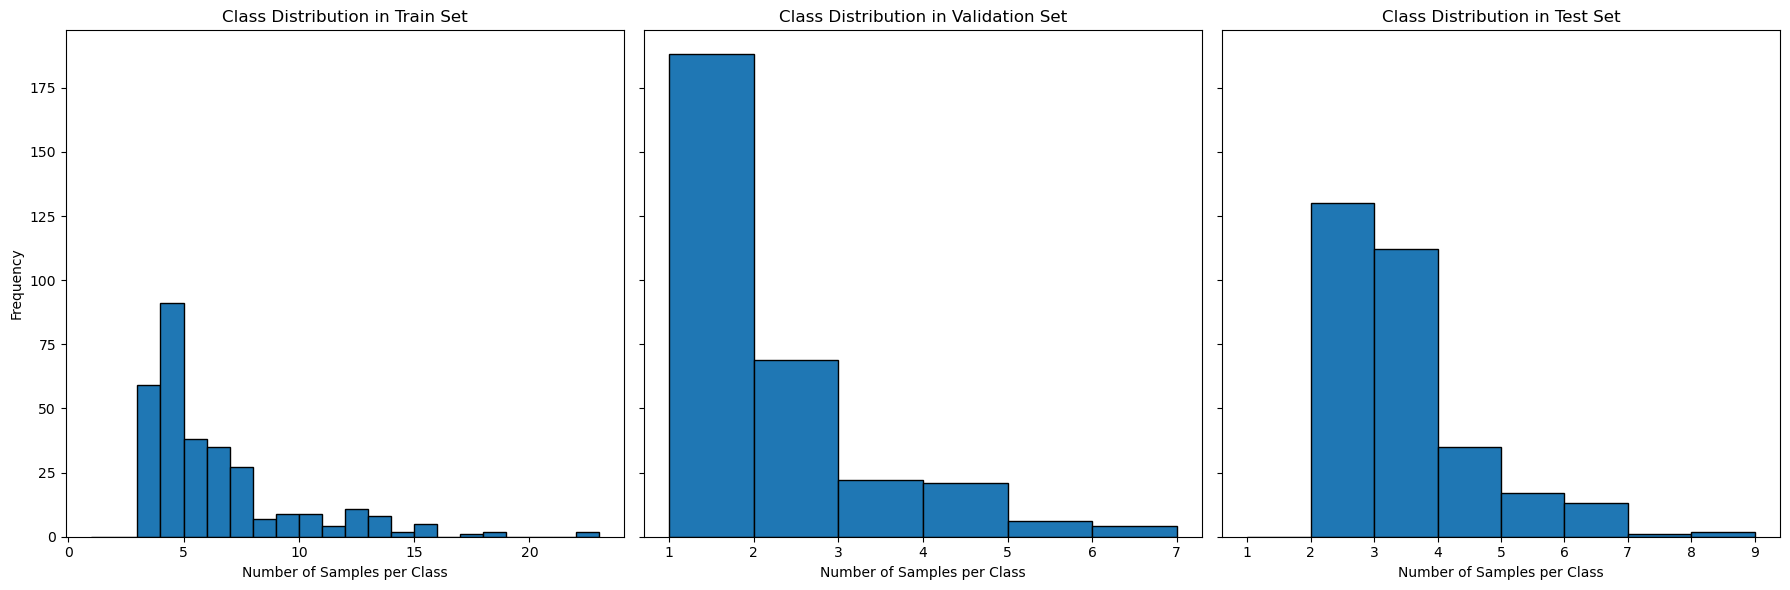

Number of different classes in the train_loader: 310
Number of different classes in the val_loader: 310
Number of different classes in the test_loader: 310
# Elephants missing in train set: 0
# Elephants missing in val set: 0
# Elephants missing in test set: 0


In [3]:

# Function to count class occurrences in a DataLoader
def count_classes(data_loader):
    class_counts = Counter()
    for batch in data_loader:
        _, _, ele_id_label, _, _, _, _, _, _, _ = batch
        class_counts.update(ele_id_label.tolist())
    return class_counts

# Count classes in train, val, and test sets
train_class_counts = count_classes(train_loader)
val_class_counts = count_classes(val_loader)
test_class_counts = count_classes(test_loader)

# Plot histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

axes[0].hist(train_class_counts.values(), bins=range(1, max(train_class_counts.values()) + 1), edgecolor='black')
axes[0].set_title('Class Distribution in Train Set')
axes[0].set_xlabel('Number of Samples per Class')
axes[0].set_ylabel('Frequency')

axes[1].hist(val_class_counts.values(), bins=range(1, max(val_class_counts.values()) + 1), edgecolor='black')
axes[1].set_title('Class Distribution in Validation Set')
axes[1].set_xlabel('Number of Samples per Class')

axes[2].hist(test_class_counts.values(), bins=range(1, max(test_class_counts.values()) + 1), edgecolor='black')
axes[2].set_title('Class Distribution in Test Set')
axes[2].set_xlabel('Number of Samples per Class')

plt.tight_layout()
plt.show()

# Print the number of different classes in each set
print(f'Number of different classes in the train_loader: {len(train_class_counts)}')
print(f'Number of different classes in the val_loader: {len(val_class_counts)}')
print(f'Number of different classes in the test_loader: {len(test_class_counts)}')

# Get unique elephant IDs in each set
train_elephants = set([dataset.label_to_ele_id[label.item()] for _, _, labels, _, _, _, _, _, _, _ in train_loader for label in labels])
val_elephants = set([dataset.label_to_ele_id[label.item()] for _, _, labels, _, _, _, _, _, _, _ in val_loader for label in labels])
test_elephants = set([dataset.label_to_ele_id[label.item()] for _, _, labels, _, _, _, _, _, _, _ in test_loader for label in labels])

# Check for elephants not represented in each set
missing_in_train = val_elephants.union(test_elephants) - train_elephants
missing_in_val = train_elephants.union(test_elephants) - val_elephants
missing_in_test = train_elephants.union(val_elephants) - test_elephants

print(f'# Elephants missing in train set: {len(missing_in_train)}')
print(f'# Elephants missing in val set: {len(missing_in_val)}')
print(f'# Elephants missing in test set: {len(missing_in_test)}')

### Training stage 1 : Concept Head
- loading a pretrained backbone, freeze it
- Train the concept head to learn the SEEK codes
- Test the concept head


In [4]:

ba = Backbone(pretraining = "savannah_elephants")
ba.freeze()

ch = ConceptHead(print_every=1, experiment_code=code)
#ch.train(train_loader, val_loader, ba, num_epochs=30)
ch.test(test_loader, ba)

ch.freeze()

ConceptHead - Test Loss: 0.0916, Test Accuracy: 78.96%
sex Accuracy: 95.01%
age Accuracy: 96.33%
right_tusk Accuracy: 80.59%
left_tusk Accuracy: 83.24%
R_tear_1 Accuracy: 57.88%
R_hole_1 Accuracy: 75.06%
R_tear_2 Accuracy: 65.46%
R_hole_2 Accuracy: 81.31%
L_tear_1 Accuracy: 58.83%
L_hole_1 Accuracy: 73.23%
L_tear_2 Accuracy: 65.82%
L_hole_2 Accuracy: 81.56%
right_extreme Accuracy: 85.10%
left_extreme Accuracy: 84.57%
ear_special Accuracy: 88.43%
body_special Accuracy: 91.00%
average Accuracy: 78.96%
whole_code Accuracy: 24.61%


### Training stage 2 : Cassifier

- With a frozen backbone, train a classifier to learn the elephant id from the backbone original embeddings
- Freeze the classifier|


In [7]:
cl = Classifier(num_classes=num_classes, criterion = ArcFaceWithMargin(num_classes), experiment_code=code, dropout= False)
#cl.optimizer = optim.Adam(cl.layer.parameters(), lr=1e-4, weight_decay=1e-3)

#cl.train(train_loader, val_loader, backbone = ba, num_epochs=30)
cl.test(test_loader, backbone = ba) 

# Freeze the classifier layer
cl.freeze()

/data/vision/beery/scratch/antoine/CBM_reid/methods/classifier.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.layer.load_state_dict(torch.load(Path.Path.cwd().par

Classifier - Test Loss: 21.0396, Test Accuracy: 2.71%


### Training stage 3 : Projector

- With a frozen backbone and the frozen classifier, train the projector
- The projector trains to project the concepts to the embedding space 
- The loss is computed such that edited embeddings (original embeddings + projected embeedings) correctly predict the elephant id using the classifier learnt is stage 2

In [8]:
def no_intervention(predicted_concepts, true_concepts, correction_probability = 0.0):
    return predicted_concepts

def intervene(predicted_concepts, true_concepts, correction_probability = 0.5):
    for i in range(predicted_concepts.shape[0]):
        if torch.rand(1).item() < correction_probability:
            predicted_concepts[i] = true_concepts[i]
    return predicted_concepts

def perfect_correction(predicted_concepts, true_concepts, correction_probability = 1.0):
    return true_concepts.to('cuda')

In [9]:
pr = Projector(experiment_code=code) 
pr.loss_fn = ArcFaceWithMargin(num_classes)

pr.optimizer = optim.Adam(pr.parameters(), lr=1e-5, weight_decay=1e-3)
ba.freeze() # freeze the backbone
ch.freeze() # freeze the concept head
cl.freeze() # freeze the classifier
pr.unfreeze() # unfreeze the projector

pr.train(train_loader, val_loader, ba,  ch, cl, num_epochs=30, intervention_fn=no_intervention, reset_wegihts=True)
pr.test(test_loader, ba, cl, ch)


training projector-  weights are reset
Concept head parameters require gradients: False 
Classifier parameters require gradients: False 
Backbone parameters require gradients: False 
Projector parameters require gradients: True
Epoch 1/30 - Train Loss: 14.6936, Train Accuracy: 77.52% - Val Loss: 20.3245, Val Accuracy: 6.97%
Epoch 2/30 - Train Loss: 14.5767, Train Accuracy: 78.35% - Val Loss: 20.2990, Val Accuracy: 7.13%
Epoch 3/30 - Train Loss: 14.4673, Train Accuracy: 79.63% - Val Loss: 20.2752, Val Accuracy: 7.13%
Epoch 4/30 - Train Loss: 14.3611, Train Accuracy: 80.24% - Val Loss: 20.2530, Val Accuracy: 7.13%
Epoch 5/30 - Train Loss: 14.2581, Train Accuracy: 81.18% - Val Loss: 20.2325, Val Accuracy: 6.97%
Epoch 6/30 - Train Loss: 14.1583, Train Accuracy: 82.37% - Val Loss: 20.2133, Val Accuracy: 7.28%
Epoch 7/30 - Train Loss: 14.0617, Train Accuracy: 83.30% - Val Loss: 20.1955, Val Accuracy: 7.44%
Epoch 8/30 - Train Loss: 13.9685, Train Accuracy: 83.93% - Val Loss: 20.1792, Val Accu

/home/conda/feedstock_root/build_artifacts/libtorch_1730760167951/work/aten/src/ATen/native/cuda/ScatterGatherKernel.cu:365: operator(): block: [0,0,0], thread: [72,0,0] Assertion `idx_dim >= 0 && idx_dim < index_size && "index out of bounds"` failed.
/home/conda/feedstock_root/build_artifacts/libtorch_1730760167951/work/aten/src/ATen/native/cuda/ScatterGatherKernel.cu:365: operator(): block: [0,0,0], thread: [73,0,0] Assertion `idx_dim >= 0 && idx_dim < index_size && "index out of bounds"` failed.
/home/conda/feedstock_root/build_artifacts/libtorch_1730760167951/work/aten/src/ATen/native/cuda/ScatterGatherKernel.cu:365: operator(): block: [0,0,0], thread: [74,0,0] Assertion `idx_dim >= 0 && idx_dim < index_size && "index out of bounds"` failed.
/home/conda/feedstock_root/build_artifacts/libtorch_1730760167951/work/aten/src/ATen/native/cuda/ScatterGatherKernel.cu:365: operator(): block: [0,0,0], thread: [75,0,0] Assertion `idx_dim >= 0 && idx_dim < index_size && "index out of bounds"` 

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


Even without correcting the concepts, we improve the accuracy. It seems that we are above the interpretability trade-off. As if, by implementing  some ecology-expertise in the model, we can do better that a blackbox MegaDescriptor.



In [83]:
pr.test(test_loader, ba, cl, ch, intervention_fn=intervene)

Test Loss: 7.0285, Test Accuracy: 27.49%


However, when correcting the concepts at inference time, this seems to be reducing accuracy. Thus we will do a 4th training stage where we correct concepts sometimes.

### Training stage 4 : Projector and Classifier jointly under partial intervention

- With the same architecture, unfreeze the classifier and the projector. Keep the concept head and the backbone frozen
- Train jointly the Projector and Classifier to maximize elephant classification
- When training, correct the concepts with probability 0.5

In [84]:
print('intervention at level 0.5')

pr.unfreeze()
cl.unfreeze()
ch.freeze()
ba.freeze()

pr.train(train_loader, val_loader, ba, ch, cl, num_epochs=30, intervention_fn = intervene, reset_wegihts=False) 


intervention at level 0.5
training projector-  weights are not reset
Concept head parameters require gradients: False 
Classifier parameters require gradients: True 
Backbone parameters require gradients: False 
Projector parameters require gradients: True


Epoch 1/30 - Train Loss: 7.0481, Train Accuracy: 25.59% - Val Loss: 7.0303, Val Accuracy: 27.31%
Epoch 2/30 - Train Loss: 7.0480, Train Accuracy: 25.67% - Val Loss: 7.0278, Val Accuracy: 27.57%
Epoch 3/30 - Train Loss: 7.0483, Train Accuracy: 25.53% - Val Loss: 7.0288, Val Accuracy: 27.48%
Epoch 4/30 - Train Loss: 7.0473, Train Accuracy: 25.65% - Val Loss: 7.0251, Val Accuracy: 27.83%
Epoch 5/30 - Train Loss: 7.0460, Train Accuracy: 25.84% - Val Loss: 7.0233, Val Accuracy: 28.00%
Epoch 6/30 - Train Loss: 7.0461, Train Accuracy: 25.78% - Val Loss: 7.0242, Val Accuracy: 27.94%
Epoch 7/30 - Train Loss: 7.0460, Train Accuracy: 25.78% - Val Loss: 7.0235, Val Accuracy: 28.09%
Epoch 8/30 - Train Loss: 7.0454, Train Accuracy: 25.83% - Val Loss: 7.0237, Val Accuracy: 28.00%
Epoch 9/30 - Train Loss: 7.0451, Train Accuracy: 25.85% - Val Loss: 7.0188, Val Accuracy: 28.46%
Epoch 10/30 - Train Loss: 7.0443, Train Accuracy: 25.92% - Val Loss: 7.0206, Val Accuracy: 28.35%
Epoch 11/30 - Train Loss: 7.0

In [ ]:
pr.test(test_loader, ba, cl, ch, intervention_fn = no_intervention)
pr.test(test_loader, ba, cl, ch, intervention_fn = intervene)
pr.test(test_loader, ba, cl, ch, intervention_fn = perfect_correction)

Test Loss: 7.0129, Test Accuracy: 29.08%
Test Loss: 7.0138, Test Accuracy: 28.99%


### Training stage 5 : ArcFace

In [6]:
import torch
import math
import torch.nn.functional as F

class ArcFaceWithMargin(torch.nn.Module):
    def __init__(self, num_classes, s=30.0, margin=0.5):
        """
        ArcFace with Angular Margin, with added numerical stability.
        Args:
            num_classes: Number of classes in the classification task.
            s: Scale factor to amplify logits for softmax.
            margin: Angular margin (in radians) to enhance class separability.
        """
        super(ArcFaceWithMargin, self).__init__()
        self.s = s  # Scale factor
        self.margin = margin  # Angular margin
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)

    def forward(self, logits: torch.Tensor, labels: torch.Tensor):
        """
        Args:
            logits: Raw logits from the linear layer (batch_size, num_classes).
            labels: Ground truth labels (batch_size,).
        Returns:
            loss: Cross-Entropy Loss with Angular Margin.
        """
        # Normalize the logits
        norm = torch.norm(logits, dim=1, keepdim=True) + 1e-8
        logits_norm = logits / norm

        # Create one-hot encoding for the labels
        one_hot = torch.zeros_like(logits).scatter(1, labels.view(-1, 1), 1.0)

        # Compute cos(theta) for the target classes
        cos_theta = logits_norm.gather(1, labels.view(-1, 1)).squeeze(1)
        cos_theta = cos_theta.clamp(-1 + 1e-7, 1 - 1e-7)  # Tighter clamping for stability

        # Calculate sin(theta)
        sin_theta_squared = 1.0 - cos_theta**2
        sin_theta_squared = sin_theta_squared.clamp(0, 1)  # Ensure no negative values
        sin_theta = torch.sqrt(sin_theta_squared)

        # Calculate cos(theta + margin)
        cos_theta_m = cos_theta * self.cos_m - sin_theta * self.sin_m

        # Ensure numerical stability for the margin update
        cos_theta_m = cos_theta_m.clamp(-1, 1)

        # Update logits with the margin
        logits_with_margin = logits_norm.clone()
        logits_with_margin.scatter_(1, labels.view(-1, 1), cos_theta_m.unsqueeze(1))

        # Scale the logits
        scaled_logits = logits_with_margin * self.s

        # Compute Cross-Entropy Loss
        loss = F.cross_entropy(scaled_logits, labels)
        #print('loss', loss)
        return loss


In [45]:
pr = Projector(experiment_code=code)
ba.freeze()
ch.freeze()
pr.unfreeze()
cl.unfreeze()

#pr.loss_fn = ArcFace(num_classes)
pr.optimizer = optim.Adam(pr.layer.parameters(), lr=1e-4, weight_decay=1e-5)
pr.loss_fn = ArcFaceWithMargin(num_classes)

pr.train(train_loader, val_loader, ba, ch, cl, num_epochs=30, intervention_fn = None, reset_wegihts=True) 
pr.test(test_loader, ba, cl, ch, intervention_fn = None)

training projector-  weights are reset
Concept head parameters require gradients: False 
Classifier parameters require gradients: True 
Backbone parameters require gradients: False 
Projector parameters require gradients: True


Epoch 1/30 - Train Loss: 18.4229, Train Accuracy: 89.50% - Val Loss: 20.6570, Val Accuracy: 7.76%
Epoch 2/30 - Train Loss: 17.7532, Train Accuracy: 87.81% - Val Loss: 20.6899, Val Accuracy: 7.40%
Epoch 3/30 - Train Loss: 17.5357, Train Accuracy: 88.04% - Val Loss: 20.6781, Val Accuracy: 8.29%
Epoch 4/30 - Train Loss: 17.3758, Train Accuracy: 90.26% - Val Loss: 20.6794, Val Accuracy: 8.96%
Epoch 5/30 - Train Loss: 17.2142, Train Accuracy: 90.80% - Val Loss: 20.6817, Val Accuracy: 8.54%
Epoch 6/30 - Train Loss: 17.1171, Train Accuracy: 91.64% - Val Loss: 20.6725, Val Accuracy: 9.10%
Epoch 7/30 - Train Loss: 17.0638, Train Accuracy: 91.88% - Val Loss: 20.6653, Val Accuracy: 8.65%
Epoch 8/30 - Train Loss: 17.0196, Train Accuracy: 92.01% - Val Loss: 20.6586, Val Accuracy: 8.54%
Epoch 9/30 - Train Loss: 16.9773, Train Accuracy: 91.93% - Val Loss: 20.6525, Val Accuracy: 8.65%
Epoch 10/30 - Train Loss: 16.9347, Train Accuracy: 91.69% - Val Loss: 20.6470, Val Accuracy: 8.54%
Epoch 11/30 - Train

/home/conda/feedstock_root/build_artifacts/libtorch_1730760167951/work/aten/src/ATen/native/cuda/ScatterGatherKernel.cu:365: operator(): block: [0,0,0], thread: [97,0,0] Assertion `idx_dim >= 0 && idx_dim < index_size && "index out of bounds"` failed.
/home/conda/feedstock_root/build_artifacts/libtorch_1730760167951/work/aten/src/ATen/native/cuda/ScatterGatherKernel.cu:365: operator(): block: [0,0,0], thread: [98,0,0] Assertion `idx_dim >= 0 && idx_dim < index_size && "index out of bounds"` failed.
/home/conda/feedstock_root/build_artifacts/libtorch_1730760167951/work/aten/src/ATen/native/cuda/ScatterGatherKernel.cu:365: operator(): block: [0,0,0], thread: [99,0,0] Assertion `idx_dim >= 0 && idx_dim < index_size && "index out of bounds"` failed.
/home/conda/feedstock_root/build_artifacts/libtorch_1730760167951/work/aten/src/ATen/native/cuda/ScatterGatherKernel.cu:365: operator(): block: [0,0,0], thread: [100,0,0] Assertion `idx_dim >= 0 && idx_dim < index_size && "index out of bounds"`

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [93]:
pr.test(test_loader, ba, cl, ch, intervention_fn = intervene)
pr.test(test_loader, ba, cl, ch, intervention_fn = perfect_correction)

/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


loss tensor(27.8805, device='cuda:0', grad_fn=<NllLossBackward0>)
loss tensor(25.5325, device='cuda:0', grad_fn=<NllLossBackward0>)
loss tensor(26.0217, device='cuda:0', grad_fn=<NllLossBackward0>)
loss tensor(26.1380, device='cuda:0', grad_fn=<NllLossBackward0>)
loss tensor(24.5870, device='cuda:0', grad_fn=<NllLossBackward0>)
loss tensor(27.4614, device='cuda:0', grad_fn=<NllLossBackward0>)
loss tensor(27.4284, device='cuda:0', grad_fn=<NllLossBackward0>)
loss tensor(26.3952, device='cuda:0', grad_fn=<NllLossBackward0>)
loss tensor(25.7046, device='cuda:0', grad_fn=<NllLossBackward0>)
loss tensor(26.5524, device='cuda:0', grad_fn=<NllLossBackward0>)
Test Loss: 26.3702, Test Accuracy: 28.16%
loss tensor(26.7230, device='cuda:0', grad_fn=<NllLossBackward0>)
loss tensor(26.6100, device='cuda:0', grad_fn=<NllLossBackward0>)
loss tensor(28.6567, device='cuda:0', grad_fn=<NllLossBackward0>)
loss tensor(26.8139, device='cuda:0', grad_fn=<NllLossBackward0>)
loss tensor(30.3853, device='cuda: